In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

from sklearn import linear_model
from sklearn.metrics import mean_squared_error

import itertools

# import tqdm tools for displaying progress bars in Jupyter notebooks
from tqdm import tnrange, tqdm_notebook
from tqdm.notebook import trange

In [2]:
def fit_linear(X,Y):
  """
  Fit linear regression model and return RSS and R-square
  """

  model = linear_model.LinearRegression(fit_intercept=True)
  model.fit(X,Y)
  RSS = mean_squared_error(Y, model.predict(X))*len(Y)
  Rsq = model.score(X,Y)
  return RSS, Rsq

Best subset selection

In [3]:
df = pd.read_csv('cancer_death_rate_abridged.csv')
df = df.dropna()

Y = df.TARGET_deathRate
X = df.drop(columns="TARGET_deathRate", axis=1)
# k = 3
RSS_list, Rsq_list, feature_list, num_of_features = [], [], [], []

for k in trange(1, len(X.columns) + 1, desc = 'Progress...'):

  # looping over all possible combinations of predictors
  for feature_combo in itertools.combinations(X.columns, k):
    fit_linear_results = fit_linear(X[list(feature_combo)], Y) # fit the data with the current set of predictors
    RSS_list.append(fit_linear_results[0]) # append RSS of the current model to 'RSS_list'
    Rsq_list.append(fit_linear_results[1]) # append R-squared of the current model to 'Rsq_list'
    feature_list.append(feature_combo)
    num_of_features.append(len(feature_combo))

# store RSS, R-squared and other attributes of each model in a DataFrame
df2 = pd.DataFrame({'num_of_features':num_of_features, 'RSS':RSS_list, 'Rsq':Rsq_list, 'features':feature_list})
df2

Progress...:   0%|          | 0/13 [00:00<?, ?it/s]

,num_of_features,RSS,Rsq,features
0,1,2.164796e+06,0.008348,"(avgDeathsPerYear,)"
1,1,1.785393e+06,0.182145,"(medIncome,)"
2,1,2.151686e+06,0.014353,"(popEst2015,)"
3,1,1.788556e+06,0.180696,"(povertyPercent,)"
4,1,2.183015e+06,0.000001,"(MedianAge,)"
...,...,...,...,...
8186,12,1.474001e+06,0.324788,"(avgDeathsPerYear, medIncome, popEst2015, Medi..."
8187,12,1.483163e+06,0.320591,"(avgDeathsPerYear, medIncome, povertyPercent, ..."
8188,12,1.462513e+06,0.330050,"(avgDeathsPerYear, popEst2015, povertyPercent,..."
8189,12,1.482106e+06,0.321075,"(medIncome, popEst2015, povertyPercent, Median..."


Identify the best subsets for each given number of features

In [4]:
RSS_group_min = df2.groupby("num_of_features")["RSS"].transform("min")
Rsq_group_max = df2.groupby("num_of_features")["Rsq"].transform("max")

print("RSS_group_min:")
print(RSS_group_min)
# print out the variable 'RSS_group_min' to show what values it stores.
# It can be seen that it has the same length as 'df2', but each entry
# stores the minimal RSS value among all RSS values of models with the same
# number of predictors. Similar story for the variable 'Rsq_group_max'.

df2_RSS_group_min = df2[df2["RSS"] == RSS_group_min]
df2_RSq_group_max = df2[df2["Rsq"] == Rsq_group_max]

display(df2_RSS_group_min)
display(df2_RSq_group_max)

RSS_group_min:
0       1.674599e+06
1       1.674599e+06
2       1.674599e+06
3       1.674599e+06
4       1.674599e+06
            ...     
8186    1.459404e+06
8187    1.459404e+06
8188    1.459404e+06
8189    1.459404e+06
8190    1.459340e+06
Name: RSS, Length: 8191, dtype: float64


,num_of_features,RSS,Rsq,features
9,1,1.674599e+06,0.232897,"(PctBachDeg25_Over,)"
72,2,1.577250e+06,0.277491,"(PercentMarried, PctBachDeg25_Over)"
362,3,1.541207e+06,0.294002,"(PctNoHS18_24, PctBachDeg25_Over, PctUnemploye..."
951,4,1.516576e+06,0.305285,"(povertyPercent, PctNoHS18_24, PctBachDeg25_Ov..."
2246,5,1.495798e+06,0.314803,"(povertyPercent, PctNoHS18_24, PctBachDeg25_Ov..."
2778,6,1.488074e+06,0.318341,"(avgDeathsPerYear, popEst2015, povertyPercent,..."
4676,7,1.470139e+06,0.326557,"(avgDeathsPerYear, popEst2015, povertyPercent,..."
6371,8,1.467015e+06,0.327988,"(avgDeathsPerYear, popEst2015, povertyPercent,..."
7196,9,1.463031e+06,0.329813,"(avgDeathsPerYear, medIncome, popEst2015, pove..."
7877,10,1.460897e+06,0.330791,"(avgDeathsPerYear, medIncome, popEst2015, pove..."


,num_of_features,RSS,Rsq,features
9,1,1.674599e+06,0.232897,"(PctBachDeg25_Over,)"
72,2,1.577250e+06,0.277491,"(PercentMarried, PctBachDeg25_Over)"
362,3,1.541207e+06,0.294002,"(PctNoHS18_24, PctBachDeg25_Over, PctUnemploye..."
951,4,1.516576e+06,0.305285,"(povertyPercent, PctNoHS18_24, PctBachDeg25_Ov..."
2246,5,1.495798e+06,0.314803,"(povertyPercent, PctNoHS18_24, PctBachDeg25_Ov..."
2778,6,1.488074e+06,0.318341,"(avgDeathsPerYear, popEst2015, povertyPercent,..."
4676,7,1.470139e+06,0.326557,"(avgDeathsPerYear, popEst2015, povertyPercent,..."
6371,8,1.467015e+06,0.327988,"(avgDeathsPerYear, popEst2015, povertyPercent,..."
7196,9,1.463031e+06,0.329813,"(avgDeathsPerYear, medIncome, popEst2015, pove..."
7877,10,1.460897e+06,0.330791,"(avgDeathsPerYear, medIncome, popEst2015, pove..."


Add RSS and Rsq values of the best subset to the DataFrame `df2`

In [5]:
df2["RSS_group_min"] = RSS_group_min
df2["Rsq_group_max"] = Rsq_group_max

df2

,num_of_features,RSS,Rsq,features,RSS_group_min,Rsq_group_max
0,1,2.164796e+06,0.008348,"(avgDeathsPerYear,)",1.674599e+06,0.232897
1,1,1.785393e+06,0.182145,"(medIncome,)",1.674599e+06,0.232897
2,1,2.151686e+06,0.014353,"(popEst2015,)",1.674599e+06,0.232897
3,1,1.788556e+06,0.180696,"(povertyPercent,)",1.674599e+06,0.232897
4,1,2.183015e+06,0.000001,"(MedianAge,)",1.674599e+06,0.232897
...,...,...,...,...,...,...
8186,12,1.474001e+06,0.324788,"(avgDeathsPerYear, medIncome, popEst2015, Medi...",1.459404e+06,0.331474
8187,12,1.483163e+06,0.320591,"(avgDeathsPerYear, medIncome, povertyPercent, ...",1.459404e+06,0.331474
8188,12,1.462513e+06,0.330050,"(avgDeathsPerYear, popEst2015, povertyPercent,...",1.459404e+06,0.331474
8189,12,1.482106e+06,0.321075,"(medIncome, popEst2015, povertyPercent, Median...",1.459404e+06,0.331474


Plot RSS and $R^2$ as a function of the number of predictors included in the model

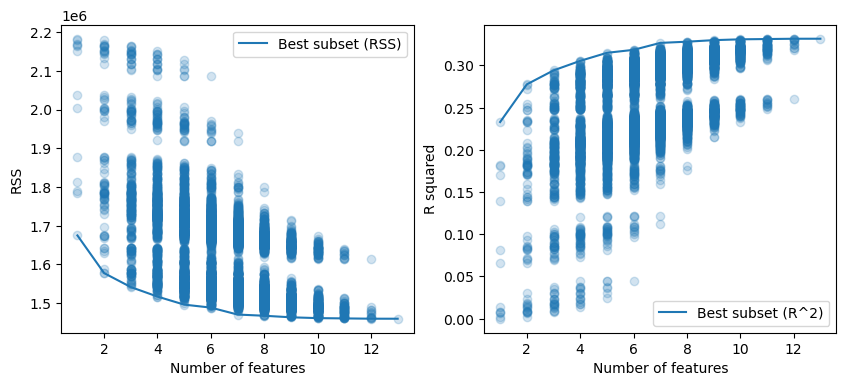

In [6]:
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(121)
ax.scatter(df2.num_of_features, df2.RSS, alpha=0.2)
ax.plot(df2.num_of_features, df2.RSS_group_min, label="Best subset (RSS)")
ax.set_xlabel("Number of features")
ax.set_ylabel("RSS")
ax.legend()

ax = fig.add_subplot(122)
ax.scatter(df2.num_of_features, df2.Rsq, alpha=0.2)
ax.plot(df2.num_of_features, df2.Rsq_group_max, label="Best subset (R^2)")
ax.set_xlabel("Number of features")
ax.set_ylabel("R squared")
ax.legend()

plt.show()


Forward stepwise selection

In [7]:
RSS_list, Rsq_list = [np.inf], [-np.inf]
feature_list, features_list_history = [], dict()

features_remaining = list(X.columns.values)

k = len(X.columns)
for i in range(1, k+1):
    best_RSS = np.inf

    for feature_combo in itertools.combinations(features_remaining,1): # add one feature from 'features_remaining' to the model and see how the model now performs

            fit_linear_results = fit_linear(X[list(feature_combo) + feature_list], Y)

            if fit_linear_results[0] < best_RSS: # if the model results in lower RSS, keep the feature we've just added
                best_RSS = fit_linear_results[0]
                best_Rsq = fit_linear_results[1]
                best_feature = feature_combo[0]

    # update features for subsequent itertions of the loop
    feature_list.append(best_feature)
    features_remaining.remove(best_feature)

    # save values for plotting
    RSS_list.append(best_RSS)
    Rsq_list.append(best_Rsq)
    features_list_history[i] = feature_list.copy()

print('Forward stepwise subset selection')
print('Number of features |', 'Features |', 'RSS')
display([(i, features_list_history[i], round(RSS_list[i])) for i in range(1,k+1)])

# combine RSS and R-squared values of forward stepwise models into a DataFrame
df3 = pd.concat([pd.DataFrame({'features':features_list_history}), pd.DataFrame({'RSS':RSS_list, 'Rsq': Rsq_list})], axis=1, join='inner')
df3['number_of_features'] = df3.index
display(df3)

Forward stepwise subset selection
Number of features | Features | RSS


[(1, ['PctBachDeg25_Over'], 1674599),
 (2, ['PctBachDeg25_Over', 'PercentMarried'], 1577250),
 (3, ['PctBachDeg25_Over', 'PercentMarried', 'PctNoHS18_24'], 1548336),
 (4,
  ['PctBachDeg25_Over',
   'PercentMarried',
   'PctNoHS18_24',
   'PctUnemployed16_Over'],
  1516752),
 (5,
  ['PctBachDeg25_Over',
   'PercentMarried',
   'PctNoHS18_24',
   'PctUnemployed16_Over',
   'BirthRate'],
  1499287),
 (6,
  ['PctBachDeg25_Over',
   'PercentMarried',
   'PctNoHS18_24',
   'PctUnemployed16_Over',
   'BirthRate',
   'povertyPercent'],
  1491297),
 (7,
  ['PctBachDeg25_Over',
   'PercentMarried',
   'PctNoHS18_24',
   'PctUnemployed16_Over',
   'BirthRate',
   'povertyPercent',
   'AvgHouseholdSize'],
  1485395),
 (8,
  ['PctBachDeg25_Over',
   'PercentMarried',
   'PctNoHS18_24',
   'PctUnemployed16_Over',
   'BirthRate',
   'povertyPercent',
   'AvgHouseholdSize',
   'medIncome'],
  1483854),
 (9,
  ['PctBachDeg25_Over',
   'PercentMarried',
   'PctNoHS18_24',
   'PctUnemployed16_Over',
   '

,features,RSS,Rsq,number_of_features
1,[PctBachDeg25_Over],1.674599e+06,0.232897,1
2,"[PctBachDeg25_Over, PercentMarried]",1.577250e+06,0.277491,2
3,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_24]",1.548336e+06,0.290736,3
4,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.516752e+06,0.305204,4
5,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.499287e+06,0.313205,5
6,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.491297e+06,0.316865,6
7,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.485395e+06,0.319569,7
8,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.483854e+06,0.320274,8
9,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.482745e+06,0.320782,9
10,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.460897e+06,0.330791,10


Calculate Mallows' $C_p$ (AIC), BIC and adjusted $R^2$

In [8]:
n = len(Y)
p = k+1

sigma_hat_sq = (1/(n-p-1)) * min(df3['RSS'])
# calculate the sigma hat squared in the Cp equation as the MSE of the full model
# (which will always be the model with the smallest RSS)

df3['C_p'] = (1/n) * (df3["RSS"] + 2 * df3["number_of_features"] * sigma_hat_sq)
df3['BIC'] = (1/n) * (df3["RSS"] + np.log(n) * df3["number_of_features"] * sigma_hat_sq)
df3['Rsq_adj'] = 1 - ( ((df3["RSS"])/(n-df3["number_of_features"]-1)) / (((Y-Y.mean())**2).sum()/(n-1))  )

display(df3)

,features,RSS,Rsq,number_of_features,C_p,BIC,Rsq_adj
1,[PctBachDeg25_Over],1.674599e+06,0.232897,1,578.795484,579.840550,0.232632
2,"[PctBachDeg25_Over, PercentMarried]",1.577250e+06,0.277491,2,545.518650,547.608782,0.276992
3,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_24]",1.548336e+06,0.290736,3,535.881354,539.016552,0.290000
4,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.516752e+06,0.305204,4,525.321337,529.501601,0.304243
5,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.499287e+06,0.313205,5,519.638816,524.864146,0.312016
6,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.491297e+06,0.316865,6,517.228743,523.499139,0.315446
7,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.485395e+06,0.319569,7,515.540081,522.855543,0.317919
8,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.483854e+06,0.320274,8,515.358087,523.718614,0.318390
9,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.482745e+06,0.320782,9,515.325164,524.730758,0.318663
10,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.460897e+06,0.330791,10,508.128118,518.578778,0.328470


In [9]:
df3

,features,RSS,Rsq,number_of_features,C_p,BIC,Rsq_adj
1,[PctBachDeg25_Over],1.674599e+06,0.232897,1,578.795484,579.840550,0.232632
2,"[PctBachDeg25_Over, PercentMarried]",1.577250e+06,0.277491,2,545.518650,547.608782,0.276992
3,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_24]",1.548336e+06,0.290736,3,535.881354,539.016552,0.290000
4,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.516752e+06,0.305204,4,525.321337,529.501601,0.304243
5,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.499287e+06,0.313205,5,519.638816,524.864146,0.312016
6,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.491297e+06,0.316865,6,517.228743,523.499139,0.315446
7,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.485395e+06,0.319569,7,515.540081,522.855543,0.317919
8,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.483854e+06,0.320274,8,515.358087,523.718614,0.318390
9,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.482745e+06,0.320782,9,515.325164,524.730758,0.318663
10,"[PctBachDeg25_Over, PercentMarried, PctNoHS18_...",1.460897e+06,0.330791,10,508.128118,518.578778,0.328470


Plot $C_p$ (AIC), BIC and adjusted $R^2$ as a function of the number of features

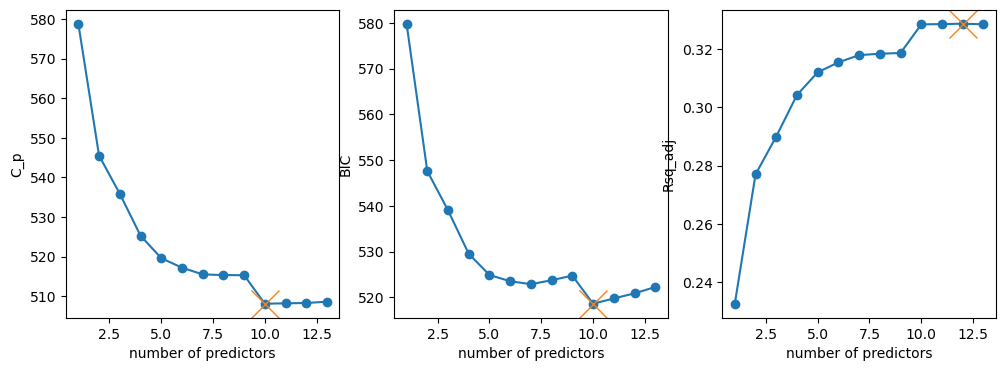

In [10]:
metrics = ['C_p', 'BIC', 'Rsq_adj']
fig = plt.figure(figsize=(12,4))

for i, curr_metric in enumerate(metrics):
  ax = fig.add_subplot(1,3,i+1)
  ax.plot(df3['number_of_features'], df3[curr_metric])
  ax.scatter(df3['number_of_features'], df3[curr_metric])

  if curr_metric == "Rsq_adj":
    ax.plot(df3[curr_metric].idxmax(), df3[curr_metric].max(), marker='x', markersize=20)
  else:
    ax.plot(df3[curr_metric].idxmin(), df3[curr_metric].min(), marker='x', markersize=20)

  ax.set_xlabel("number of predictors")
  ax.set_ylabel(curr_metric)

plt.show()